In [1]:
import pymc as pm
import numpy as np
import arviz as az
import random as rm
from scipy import stats
import pandas as pd

import matplotlib.pyplot as plt
import gc
from IPython.display import Image
import graphviz
import math
import seaborn as sns
print(f"Running on PyMC v{pm.__version__}")

Running on PyMC v5.23.0


In [ ]:
######### Generate simulated data if needed or read in file #########
agentCols=[]

# Reading the dataset from the file. 
df = pd.read_csv ('AgentsWithMetaData.csv')#pd.read_csv ('AgentsWithMetaData.csv')

useDummyData = False # We have real data so not needed
doPredictions=True



#Create a fake dataset with appropriate column names for usage later

if useDummyData:
  # Creating some agents to see if we can recover the right values of the abilities

  length = df["InstanceName"].count()
  #df.append()

  #df['randomAgent'] = np.random.uniform(0,1,length).round()
  df['75percentCorrectAgent'] = [1,1,0,1]*math.ceil(length/4)
  df['50percentCorrectAgent'] = [0,1]*math.ceil(length/2)
  df['25percentCorrectAgent'] = [0,1,0,0]*math.ceil(length/4)
  df['perfectAgent'] = [1]*length
  df['worstAgent'] = [0]*length
  df['perfectAgentWhenNoLava'] = 1 - df["LavaPresence"]
  df['perfectAgentTimeBelowThree'] = (df["TimeUnderOcclusion"] < 3) * 1.0  # Ignoring everything else as being solved by the agent the ability would be at least 11 * 2.5 = 27.5
  #df['perfectAgentTimeBelowTwo'] = (df["TimeUnderOcclusion"] < 2) * 1.0  # Ignoring everything else as being solved by the agent the ability would be at least 11 * 1.5 = 16.5
  #df['perfectAgentPositionsBelowTen'] = (df["TimeUnderOcclusion"] * df["NumOtherPositionsAvailable"] < 10) * 1.0  # Ignoring everything else as being solved by the agent the ability would be exactly 10
  df['AgentNoObjPerm'] = (df["TimeUnderOcclusion"] * df["NumOtherPositionsAvailable"] == 0.0) * 1.0  # Ignoring everything else as being solved by the agent the ability would be exactly 0
  df['AgentNoObjPermOrLava'] = (df["TimeUnderOcclusion"] + df["LavaPresence"] == 0) * 1.0
  df['AgentNoObjPermOrRamp'] = (df["TimeUnderOcclusion"] + df["RampPresence"] == 0) * 1.0
  agentCols = df.columns[df.columns.str.contains(r'\D*Agent[^0-9]*$')] ## Doesn't include the ones with numbers at the end from the table.
  print(agentCols)


else:
  
  agentCols = df.columns[df.columns.str.contains('Agent')]
  print(agentCols)
 


Index(['Agent1', 'Agent2', 'Agent3', 'Agent4', 'Agent5', 'Agent6', 'Agent7',
       'Agent8', 'Agent9', 'Agent10', 'Agent11', 'Agent12', 'Agent13',
       'Agent14', 'Agent15', 'Agent16', 'Agent17', 'Agent18', 'Agent19',
       'Agent20', 'Agent21', 'Agent22', 'Agent23', 'Agent24', 'Agent25',
       'Agent26', 'Agent27', 'Agent28', 'Agent29', 'Agent30'],
      dtype='object')


In [3]:
####Clean up feature data columns#######

df['OccluderPresence']= (df['TimeUnderOcclusion'] != 0) * 1.0   # Creating new variable for OccluderPresence
df['NumOtherPositionsAvailable'] = df['NumOtherPositionsAvailable'].fillna(0)  # Replace nans by 0s
df['GoalSize']=df['GoalSize'].astype(np.double)
df["OccluderRedness"]=df["OccluderRedness"].fillna(0)
df["OccluderGreenness"]=df["OccluderGreenness"].fillna(0)
df["OccluderBlueness"]=df["OccluderBlueness"].fillna(0)
#Print unique values for key features
print('TimeUnderOcclusion: ',df['TimeUnderOcclusion'].unique())
print('RightLeftPosition: ',df['RightLeftPosition'].unique())
print('NumOtherPositionsAvailable: ',df['NumOtherPositionsAvailable'].unique())
print('Goal sizes: ',df['GoalSize'].unique())
print('Occluder Colours: ',df['OccluderColour'].unique())  # Still need to have an extra arrow to occluder for nans

#Print head of dataframe
print(df.head())
#df.describe()
#df.count()

TimeUnderOcclusion:  [3 1 2 4 0]
RightLeftPosition:  [-1  1  0]
NumOtherPositionsAvailable:  [ 1  2  3  7 11  0]
Goal sizes:  [2.  0.5 1.  2.5 3.  1.5 4.  5.  3.5]
Occluder Colours:  ['Beige' 'Brown' 'DarkBlue' 'DarkGreen' 'Grey' 'OffWhite' 'Blue' nan]
           Suite Paradigm                                       InstanceName  \
0  AllocentricOP  CVChick  OP-STC-Allo-CVChick-1Occluder-Left-Beige-0-OPQ...   
1  AllocentricOP  CVChick  OP-STC-Allo-CVChick-1Occluder-Left-Brown-0-OPQ...   
2  AllocentricOP  CVChick  OP-STC-Allo-CVChick-1Occluder-Left-DarkBlue-0-...   
3  AllocentricOP  CVChick  OP-STC-Allo-CVChick-1Occluder-Left-DarkGreen-0...   
4  AllocentricOP  CVChick  OP-STC-Allo-CVChick-1Occluder-Left-Grey-0-OPQ.yml   

      AbilityTested  GoalVisibleAtChoicePoint  RequiresOP?  LavaPresence  \
0  CVChickLikeTasks                         0            1             1   
1  CVChickLikeTasks                         0            1             1   
2  CVChickLikeTasks                   

In [4]:
#### Train - Test split
if doPredictions:
  dfTrain = df.sample(frac=0.8)
  dfTest = df.drop(dfTrain.index)
  df=dfTrain

In [ ]:
######Define values & functions that will be used to define the model later########
uniformAbilitySlack = 1.2 # Constant to multiply the maximum of abilities that are uniform to allow for the value to be above the maximum observable value for the corresponding feature

#Decide "maximum capabilities" based on the hardest values in the dataset
maxTime = max(df["TimeUnderOcclusion"])
print('maxTime: ', maxTime)
maxPositions = max(df["NumOtherPositionsAvailable"])
print('maxPositions: ',maxPositions)
maxGoalSize= max(df["GoalSize"])
print('maxGoalSize: ', maxGoalSize)
maxPermAbility = maxTime* maxPositions* uniformAbilitySlack
print('maxPermAbility: ', maxPermAbility)
maxMemoryAbility = maxTime * uniformAbilitySlack
print('maxMemoryAbility: ', maxMemoryAbility)
maxDistanceToGoal= max(df["DistanceToGoalManhattan"])
print('maxDistanceToGoal: ', maxDistanceToGoal)

#Define useful functions for use within the model

def scaledBeta(name, a, b, min, max):

  beta = pm.Beta(f"{name}_raw", a, b)
  return pm.Deterministic(name, beta * (max - min) + min)


def logistic(x):
  return 1 / (1 + np.exp(-x))

def SimplePrMargin(ability, binaryFeature): # must return a value between 0 and 1
  return 1-((1-ability)*binaryFeature)  # If binaryFeature is 0 then the margin represents p(success)=1. If binaryFeature = 1 then p(success)=ability

# updated to set margin as max when no occluder is present
def objPermanenceLOMargin(ability, occluderPresence, timeUnderOcclusion, numPositions): #,  visualAcuityP): # must return a value between -inf and inf (more precisely between -maxPermAbility and maxPermAbility)
  OPPerformance = ability  - timeUnderOcclusion * numPositions
  return maxPermAbility-((maxPermAbility-OPPerformance)*occluderPresence)
  #return ability  - occluderPresence * timeUnderOcc * numPositions  # Goes between -inf to inf, with logodds=0 meaning this would lead to 0.5 chance of success
  #  return ability - timeUnderOcc * maxPositions - numPositions * maxTime  # Keeping same ranges but making it additive and possibly easier
  # It's probably better to use some weighted generalised mean, but for the moment the product makes more sense

def visualAcuityLOMargin(ability, goalSmallness): # must return a value between -inf and inf  (more precisely between -maxVisualAcuityAbility and maxVisualAcuityAbility)
  return ability - goalSmallness   # Goes between -inf to inf, with logodds=0 meaning this would lead to 0.5 chance of success

def memoryLOMargin(ability, timeUnderOcc): # must return a value between -inf and inf  (more precisely between -maxMemoryAbility and maxMemoryAbility)
  return ability - timeUnderOcc   # Goes between -inf to inf, with logodds=0 meaning this would lead to 0.5 chance of success



def flatNavMargin(ability, distanceToGoal): # must return a value between -inf and inf  (more precisely between -maxSpatialAbility and maxSpatialAbility)
  return ability - distanceToGoal   # Goes between -inf to inf, with logodds=0 meaning this would lead to 0.5 chance of success


def navigationPrMargin(simpleNavigationP, lavaP, rampP, platP) :  # , visualAcuityP): # must return a value between 0 and 1
  #   return (simpleNavigationP + lavaP + rampP + platP) / 4  # This is the only case where an ability goes directly to a performance, without any feature of the instance intermediating. Perhaps if we had distance...
                                                            # By dividing by four, we keep the range 0..1
  return simpleNavigationP * lavaP * rampP * platP # * visualAcuityP  # I think a product makes more sense, since if lavaPerf is zero, this means there's lava and the ability of handling lava is zero, with a high probability of failure.
  # It's probably better to use some weighted generalised mean, but for the moment the product makes more sense

def finalTaskPrMargin(objPermanenceP, navigationP, visualAcuityP): # must return a value between 0 and 1
  #  return (objPermanenceP + navigationP)/2
  return objPermanenceP * navigationP * visualAcuityP       # Again I consider that we need both things if we do have both things.

abilityMin = {} #Initialize ability Min and max dataframes for plotting ranges
abilityMax = {}

maxTime:  4
maxPositions:  11
maxGoalSize:  5.0
maxPermAbility:  52.8
maxMemoryAbility:  4.8
maxDistanceToGoal:  56


In [ ]:
###### Define function that generates a PyMC model following our theorised structure. This will be called once for each agent.
includeIrrelevantFeatures = True
includeNoise = True
memoryEffect = "directIndirect" # "none" if ignoring memory entirely # "directIndirect" if memory goes to both performance and OP ability
def SetupModel(taskResults):
  m = pm.Model()
  with m:

    ## Define priors (about the agent)
    #memory & OP abilities
    if memoryEffect == "none":
      abilityMin["objPermAbility"] = 0
      abilityMax["objPermAbility"] = maxPermAbility
    elif memoryEffect == "directOnly":
      memoryAbility = pm.Uniform("memoryAbility", 0, maxMemoryAbility)  # [0,maxMemoryAbility] This is the same as above, but we have the ability in the right magnitude
      abilityMin["memoryAbility"] = 0
      abilityMax["memoryAbility"] = maxMemoryAbility

      objPermAbility = pm.Uniform("objPermAbility", 0, maxPermAbility)  # [0,maxPermAbility] This is the same as above, but we have the ability in the right magnitude
      abilityMin["objPermAbility"] = 0
      abilityMax["objPermAbility"] = maxPermAbility
    elif memoryEffect == "directIndirect":
      memoryAbility = pm.Uniform("memoryAbility", 0, maxMemoryAbility)  # [0,maxMemoryAbility] This is the same as above, but we have the ability in the right magnitude
      abilityMin["memoryAbility"] = 0
      abilityMax["memoryAbility"] = maxMemoryAbility

      objPermAbility = pm.Uniform("objPermAbility", 0, memoryAbility * maxPositions )  # [0,maxPermAbility]  # This introduces memoryAbility in a product, so mostly non-compensatory and as a cap.
      abilityMin["objPermAbility"] = 0
      abilityMax["objPermAbility"] = maxMemoryAbility * maxPositions

    #Visual acuity
    maxVisualAcuityAbility = maxGoalSize* uniformAbilitySlack                       # The 1.1 is to have some margin to see also if it overestimates in those cases where this ability is maximal
    visualAcuityAbility = pm.Uniform("visualAcuityAbility", 0, maxVisualAcuityAbility)
    abilityMin["visualAcuityAbility"] = 0
    abilityMax["visualAcuityAbility"] = maxVisualAcuityAbility

    
    flatNavAbility = pm.Uniform("flatNavAbility", 0, maxDistanceToGoal)                 # [-inf,inf] This is an ability centered on 0, as it is used directly as a logit joinlty with the Left/Right influence
    abilityMin["flatNavAbility"] =0
    abilityMax["flatNavAbility"] =maxDistanceToGoal
    lavaAbility = pm.Beta("lavaAbility", 1,1)                        # [0,1] Specific ability with lava
    abilityMin["lavaAbility"] = 0
    abilityMax["lavaAbility"] = 1
    
    platformAbility = pm.Beta("platformAbility",1,1)                  # [0,1] Specific ability with platforms
    abilityMin["platformAbility"] = 0
    abilityMax["platformAbility"] = 1
    
    rampAbility = pm.Beta("rampAbility",1,1)                          # [0,1] Specific ability with ramps
    abilityMin["rampAbility"] = 0
    abilityMax["rampAbility"] = 1
   

    # Other properties of the agent that we wouldn't call abilities, we can call them "bias"

    if (includeIrrelevantFeatures) :
      rightLeftBias = pm.Normal("rightLeftBias", 0,1)                  # [-inf,inf] A parameter to determine whether left or right have an influence. It's expected to be zero, but negative would be left influence and positive a right influence (or vice versa :-)
      abilityMin["rightLeftBias"] = -np.inf
      abilityMax["rightLeftBias"] = np.inf
      rednessBias = pm.Normal("rednessBias", 0,1)                      # [-inf,inf] A parameter to determine whether redness has an influence
      abilityMin["rednessBias"] = -np.inf
      abilityMax["rednessBias"] = np.inf
      greennessBias = pm.Normal("greennessBias", 0,1)                  # [-inf,inf] A parameter to determine whether greenness has an influence
      abilityMin["greennessBias"] = -np.inf
      abilityMax["greennessBias"] = np.inf
      bluenessBias = pm.Normal("bluenessBias", 0,1)                    # [-inf,inf] A parameter to determine whether blueness has an influence
      abilityMin["bluenessBias"] = -np.inf
      abilityMax["bluenessBias"] = np.inf

    ## Environment variables as Deterministic (about the instance)
    ## RELEVANT
    lavaPresence = pm.MutableData("lavaPresence", df["LavaPresence"].values)
    rampPresence = pm.MutableData("rampPresence", df["RampPresence"].values)
    platformPresence = pm.MutableData("platformPresence", df["PlatformPresence"].values)
    timeUnderOcc = pm.MutableData("timeUnderOcc", df["TimeUnderOcclusion"].values)
    numPositions = pm.MutableData("numPositions", df["NumOtherPositionsAvailable"].values)
    occluderPresence = pm.MutableData("occluderPresence", df["OccluderPresence"].values)
    goalSize = pm.MutableData("goalSize",df["GoalSize"].values)
    
    goalDist = pm.MutableData("goalDistance", df["DistanceToGoalManhattan"])

    ## SUPPOSEDLY IRRELEVANT
    if (includeIrrelevantFeatures) :
      rightLeftPosition = pm.MutableData("rightLeftPosition", df["RightLeftPosition"].values)


    goalSmallness = maxGoalSize - goalSize
    visualAcuityP = pm.Deterministic("visualAcuityP", logistic(visualAcuityLOMargin(visualAcuityAbility, goalSmallness)))

    if (includeIrrelevantFeatures) :
      rightLeftEffect = pm.Deterministic("rightLeftEffect", rightLeftBias * rightLeftPosition)
    else :
      rightLeftEffect = 0

  
    flatNavP = pm.Deterministic("flatNavP", logistic(flatNavMargin(flatNavAbility, goalDist) + rightLeftEffect))

    
    lavaP = pm.Deterministic("lavaP", SimplePrMargin(lavaAbility, lavaPresence))
   
    rampP = pm.Deterministic("rampP", SimplePrMargin(rampAbility, rampPresence))
    #
    platformP = pm.Deterministic("platformP", SimplePrMargin(platformAbility, platformPresence))
  
    navP = pm.Deterministic("navP", navigationPrMargin(flatNavP, lavaP, rampP, platformP)) #, visualAcuityP))
    
    occluderColourEffect = 0  # To ignore the effect of colour in the model

    if memoryEffect == "none":
      #OP performance determined by OP ability plus occluder presence, time under occlusion and numpositions. Memory considered part of OP
      OPLOM = objPermanenceLOMargin(objPermAbility, occluderPresence, timeUnderOcc, numPositions) # , visualAcuityP)
      logisticOPLOM = logistic(OPLOM + occluderColourEffect)
      objPermP = pm.Deterministic("objPermP", logistic(OPLOM + occluderColourEffect))
    else:
      MEMM = memoryLOMargin(memoryAbility, timeUnderOcc)
      memoryP = pm.Deterministic("memoryP", logistic(MEMM))
      if memoryEffect == "directIndirect":
        #OP performance determined by memory ability, max time and number of positions - but if no occluder, OP performance should be at maximum. Memory considered to feed into OP and OP performance
        OPLOM = objPermanenceLOMargin(objPermAbility, occluderPresence, maxTime, numPositions) # , visualAcuityP)  # We set timeUnderOcc=maxTime because this has been considered already by memoryP, which will be used later on
        objPermP = pm.Deterministic("objPermP", memoryP * logistic(OPLOM + occluderColourEffect))
      elif memoryEffect == "directOnly":
        #OP performance determined by OP ability plus numpositions. Memory considered separate to OP
        OPLOM = objPermanenceLOMargin(objPermAbility, occluderPresence, maxTime, numPositions) # , visualAcuityP)  # We set timeUnderOcc=maxTime because this has been considered already by memoryP, which will be used later on
        objPermP = pm.Deterministic("objPermP", memoryP * logistic(OPLOM + occluderColourEffect))

    
    if includeNoise :
      
      noise = 1 - np.mean(taskResults)  # With this noise is complementary to result prior.
      noisePar = pm.Uniform("noisePar", 0, 1)
      finalP = pm.Deterministic("finalP", (1-noisePar)*finalTaskPrMargin(objPermP, navP, visualAcuityP)+(noisePar*noise))
      taskPerformance = pm.Bernoulli("taskPerformance", finalP, observed=taskResults)
    else :
      taskPerformance = pm.Bernoulli("taskPerformance", finalTaskPrMargin(objPermP, navP, visualAcuityP), observed=taskResults)
    
  pm.model_graph.model_to_graphviz(m)

  return m

/home/john/miniconda3/envs/MeasLay/lib/python3.12/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(


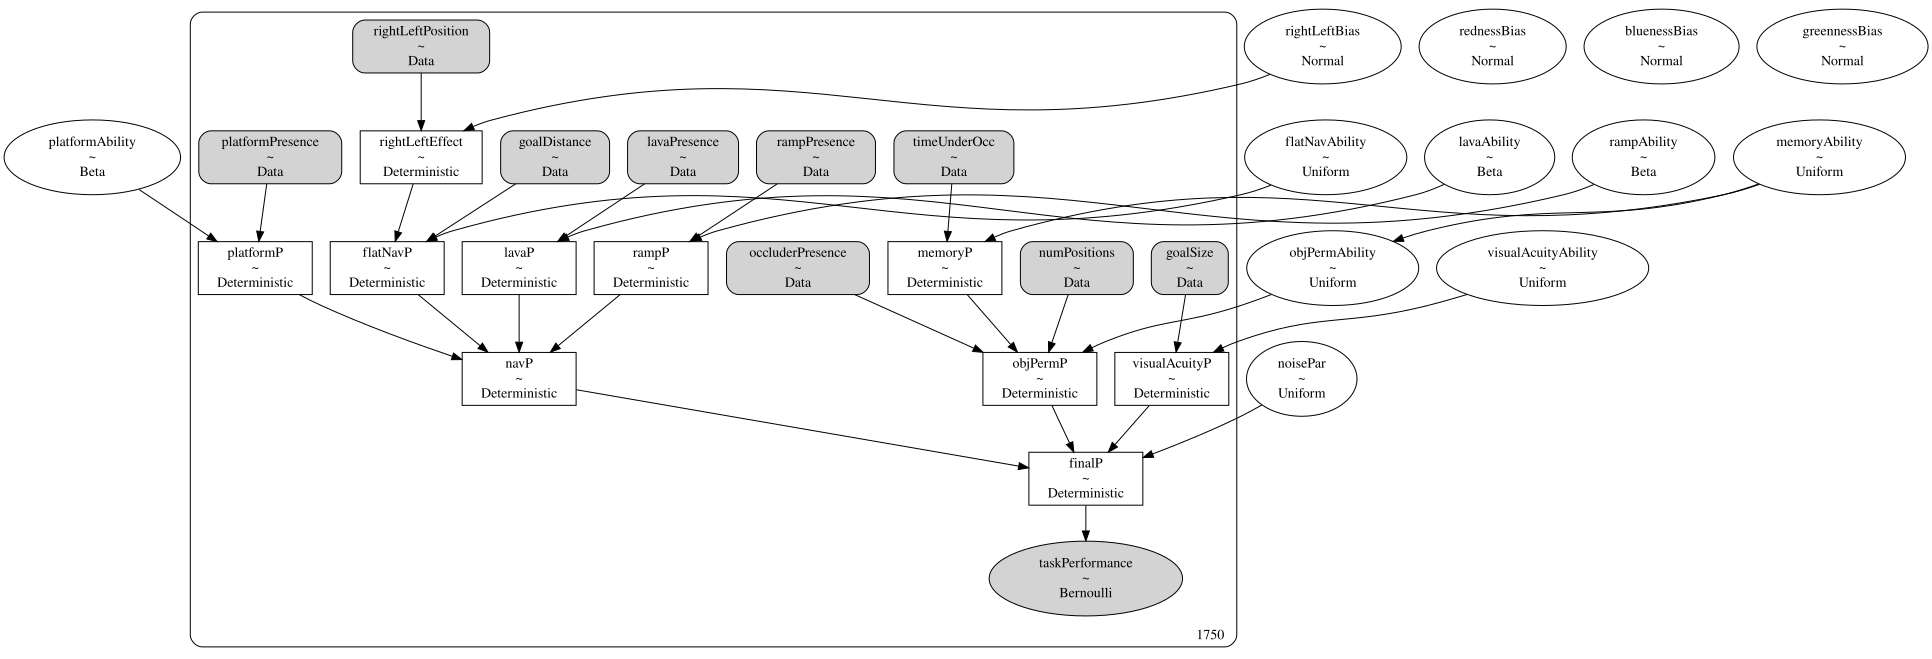

In [ ]:

taskResults = df["Agent1"] #set task results with first agent just to generate the model diagram
m = SetupModel(taskResults)
gv = pm.model_graph.model_to_graphviz(m)
gv.format="png"
gv.render
gv.render(directory='viz')
Image("viz/Digraph.gv.png")
gv


In [ ]:
def analyzeAgentResults(agentName, agentData, displayFigs=False):


  abilitySDs = []
  for a in abilitiesToShow: #iterate through each ability, add posterior mean to dataframe, and plot posterior
   
    posteriorMean = float(np.mean(agentData['posterior'][a])) # calculate posterior mean
    posteriorSD = float(np.std(agentData['posterior'][a])) #calculate posterior sd
    abilityMeans.append(posteriorMean)
    abilitySDs.append(posteriorSD)
      return abilityMeans, abilitySDs

In [ ]:
########## Useful functions for prediction


def pad(testingData, trainingDataSize):
    return pd.concat([testingData, pd.Series(np.zeros(trainingDataSize-len(testingData), dtype=int))])



def predict(m, agentData, dfTest, agent):
  with m:
    pm.set_data({"goalDistance": pad(dfTest["DistanceToGoalManhattan"], 1750)})
    pm.set_data({"lavaPresence": pad(dfTest["LavaPresence"], 1750)})
    pm.set_data({"rampPresence": pad(dfTest["RampPresence"], 1750)})
    pm.set_data({"platformPresence": pad(dfTest["PlatformPresence"], 1750)})
    pm.set_data({"timeUnderOcc": pad(dfTest["TimeUnderOcclusion"], 1750)})
    pm.set_data({"numPositions": pad(dfTest["NumOtherPositionsAvailable"], 1750)})
    pm.set_data({"occluderPresence": pad(dfTest["OccluderPresence"], 1750)})
    pm.set_data({"goalSize": pad(dfTest["GoalSize"], 1750)})
    pm.set_data({"rightLeftPosition": pad(dfTest["RightLeftPosition"], 1750)})
    predictions=pm.sample_posterior_predictive(agentData, var_names=["finalP"], return_inferencedata=False,predictions=True,extend_inferencedata=False)
    predictionChainRuns =predictions["finalP"][:,:,0:len(dfTest)]
    predictionsInstance = np.mean(predictionChainRuns, (0,1))

    return predictionsInstance,  dfTest[agent].to_numpy()


def brierScore(preds, outs):
    return 1/len(preds) * sum( (preds-outs)**2 )

def brierDecomp(preds, outs):

  brier= 1/len(preds) * sum( (preds-outs)**2 )
  ## bin predictions
  bins = np.linspace(0,1,11)
  binCenters = (bins[:-1] +bins[1:]) /2
  binPredInds = np.digitize(preds,binCenters)
  binnedPreds = bins[binPredInds]

  binTrueFreqs = np.zeros(10)
  binPredFreqs = np.zeros(10)
  binCounts = np.zeros(10)

  for i in range(10):
      idx = (preds >= bins[i]) & (preds < bins[i+1])

      binTrueFreqs[i] = np.sum(outs[idx])/np.sum(idx) if np.sum(idx) > 0 else 0
     
      binPredFreqs[i] = np.mean(preds[idx]) if np.sum(idx) > 0 else 0
      binCounts[i] = np.sum(idx)

  calibration = np.sum(binCounts * (binTrueFreqs - binPredFreqs) ** 2) / np.sum(binCounts) if np.sum(binCounts)>0 else 0
  refinement = np.sum(binCounts * (binTrueFreqs *(1 - binTrueFreqs))) / np.sum(binCounts) if np.sum(binCounts)> 0 else 0
 
  return brier, calibration, refinement

In [11]:
##### Sample results for each agent using the model defined in the function above.
allAgentData = [] #blank list for entering the outputs of the pm sampling for each agent
agentNames = [] #blank list for the agent names
agentColList = agentCols.tolist()
print(agentColList)
numAgents = len(agentColList) #Number of agents, replace with a small number for testing to save time
print(numAgents)

objPermAbilityList = []
flatNavAbilityList = []
visualAcuityAbilityList = []
lavaAbilityList = []
platformAbilityList = []
rampAbilityList = []
memoryAbilityList = []
rightLeftBiasList = []


abilitiesToShow = ["objPermAbility", "flatNavAbility", "visualAcuityAbility","lavaAbility", "platformAbility", "rampAbility"]
if memoryEffect != "none":
    abilitiesToShow.append("memoryAbility")
if (includeIrrelevantFeatures) :
  abilitiesToShow = abilitiesToShow + ["rightLeftBias"]
if (includeNoise) :
  abilitiesToShow = abilitiesToShow + ["noisePar"] # ["noise", "noisePar"]

includePerformance = True


abilityDF = pd.DataFrame( {'Ability': abilitiesToShow})
meansDF = pd.DataFrame({"Ability": abilitiesToShow})
stdDevDF = pd.DataFrame({"Ability": abilitiesToShow})
modelBrierScores = []
aggregateBrierScores = []
modelCalibrations = []
aggregateCalibrations = []
modelRefinements = []
aggregateRefinements = []




if (includePerformance):
  abilitiesToShow2 = abilitiesToShow + ["Success"]
  abilityDF2 = pd.DataFrame( {'Ability': abilitiesToShow2})
  meansDF2 = pd.DataFrame({'Ability': abilitiesToShow2})
  stdDevDF2 = pd.DataFrame({"Ability": abilitiesToShow2})
for i in range(numAgents): # Iterate through each agent.
  agent = agentCols[i] #Get the agent name
  taskResults = df[agent] #Grab the column of results for that agent
  print(agent)
  print(np.mean(taskResults)) #print mean performance for the agent across all tasks
  m = SetupModel(taskResults) #Define the model using the setupModel function. Needs to be redefined each run after taskResults are updated or PyMC won't use the latest taskResults

  #Now sample based on this agent's performance
  with m:
    agentData = pm.sample(2000, target_accept=0.975, chains=4) #Might need more samples to converge


  objPermAbilityList.append(agentData['posterior']['objPermAbility'])
  flatNavAbilityList.append(agentData['posterior']['flatNavAbility'])
  visualAcuityAbilityList.append(agentData['posterior']['visualAcuityAbility'])
  lavaAbilityList.append(agentData['posterior']['lavaAbility'])
  platformAbilityList.append(agentData['posterior']['platformAbility'])
  rampAbilityList.append(agentData['posterior']['rampAbility'])
  memoryAbilityList.append(agentData['posterior']['memoryAbility']) 
  rightLeftBiasList.append(agentData['posterior']['rightLeftBias']) 
  

  mu, sd  = analyzeAgentResults(agent, agentData)
  if doPredictions:
    predictions, testOutputs = predict(m, agentData, dfTest, agent)
    agentBrierScore, agentCalibration, agentRefinement = brierDecomp(predictions, testOutputs)
    agentAggBrierScore, agentAggCalibration, agentAggRefinement = brierDecomp(np.repeat(np.mean(taskResults), len(testOutputs)), testOutputs)
    aggregateBrierScores.append(agentAggBrierScore)
    aggregateCalibrations.append(agentAggCalibration)
    aggregateRefinements.append(agentAggRefinement)
    modelBrierScores.append(agentBrierScore)
    modelCalibrations.append(agentCalibration)
    modelRefinements.append(agentRefinement)
  abilityMeans= [str(round(mu_i, 2))+" " for mu_i in mu]  # add ability mean estimate to list for this agent
  abilitySDs = [""+str(round(sd_i,2)) for sd_i in sd ]



  abilityDF[agent] = list(zip(abilityMeans, abilitySDs))
  meansDF[agent] =  [ round(mu_i,2) for mu_i in mu]
  stdDevDF[agent] = [round(sd_i, 2) for sd_i in sd]
  if (includePerformance):
    abilityMeans = abilityMeans + [str(round(np.mean(taskResults),2))+" "]
    abilitySDs = abilitySDs + [str(round(np.std(taskResults), 2))]
    abilityDF2[agent] = list(zip(abilityMeans, abilitySDs))
    mu=mu+[np.mean(taskResults)]
    sd=sd+[np.std(taskResults)]
    meansDF2[agent]=[round(mu_i,2) for mu_i in mu]
    stdDevDF2[agent]=[round(sd_i,2) for sd_i in sd]

if (includePerformance):
  abilityDF = abilityDF2
  meansDF = meansDF2
  stdDevDF = stdDevDF2


['Agent1', 'Agent2', 'Agent3', 'Agent4', 'Agent5', 'Agent6', 'Agent7', 'Agent8', 'Agent9', 'Agent10', 'Agent11', 'Agent12', 'Agent13', 'Agent14', 'Agent15', 'Agent16', 'Agent17', 'Agent18', 'Agent19', 'Agent20', 'Agent21', 'Agent22', 'Agent23', 'Agent24', 'Agent25', 'Agent26', 'Agent27', 'Agent28', 'Agent29', 'Agent30']
30
Agent1
1.0


/home/john/miniconda3/envs/MeasLay/lib/python3.12/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
/home/john/miniconda3/envs/MeasLay/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2968: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Multiprocess sampling (4 chains in 4 jobs)
N

Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 22 seconds.
Sampling: []


Output()

...

Agent30
0.624


/home/john/miniconda3/envs/MeasLay/lib/python3.12/site-packages/pymc/data.py:265: FutureWarning: MutableData is deprecated. All Data variables are now mutable. Use Data instead.
  warnings.warn(
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [memoryAbility, objPermAbility, visualAcuityAbility, flatNavAbility, lavaAbility, platformAbility, rampAbility, rightLeftBias, rednessBias, greennessBias, bluenessBias, noisePar]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 26 seconds.
Sampling: []


Output()

In [12]:
np.array(modelBrierScores)<np.array(aggregateBrierScores)

array([False, False,  True,  True, False,  True, False, False,  True,
        True,  True,  True,  True,  True, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [14]:
print(modelBrierScores)
print(modelCalibrations)
print(modelRefinements)
print(aggregateBrierScores)
print(aggregateCalibrations)
print(aggregateRefinements)
meansDF.iloc[9]

[0.02853569040051013, 0.25032767376461595, 0.11628449918582627, 0.024519322736629073, 0.11308518896212891, 0.06338401630812673, 0.14370701320698148, 0.1143259711025767, 0.07674182517700698, 0.21568983254716678, 0.18395920805360386, 0.20206055616946664, 0.2293500862023571, 0.1612922424936306, 0.03576093311239626, 0.07496752842813496, 0.08558123759345872, 0.09537441681442257, 0.06551447517312897, 0.21857976378723215, 0.16614576683947044, 0.1941772665864346, 0.0119208585130623, 0.14902583109059206, 0.1672024544520983, 0.2300003303954959, 0.08605157887836244, 0.20484618025954351, 0.08360357150508918, 0.19812875333836472]
[0.02802512984335701, 0.0003365477275152121, 0.0013730782149021473, 0.00010151973305153011, 0.024420394054088117, 0.013099745910928873, 0.018791285895669505, 0.021710241572839153, 0.002326392974721565, 0.0036766862613632294, 0.010883782286139898, 0.008205588018702484, 0.0028276329105465505, 0.016076588253710184, 0.02501980281018696, 0.01761519448621101, 0.01945718213264437

Ability    Success
Agent1         1.0
Agent2         0.5
Agent3        0.09
Agent4        0.03
Agent5         0.9
Agent6        0.53
Agent7        0.86
Agent8        0.87
Agent9        0.61
Agent10       0.63
Agent11        0.6
Agent12       0.61
Agent13       0.62
Agent14       0.79
Agent15       0.99
Agent16       0.94
Agent17        0.8
Agent18       0.92
Agent19       0.53
Agent20       0.45
Agent21       0.43
Agent22       0.38
Agent23        0.5
Agent24       0.43
Agent25       0.73
Agent26       0.57
Agent27        0.7
Agent28       0.56
Agent29        0.8
Agent30       0.62
Name: 9, dtype: object

In [15]:
print(meansDF)

               Ability  Agent1  Agent2  Agent3  Agent4  Agent5  Agent6  \
0       objPermAbility   50.26   13.32   13.11   12.23   49.99   49.98   
1       flatNavAbility   55.97   25.51    7.85   11.81   55.96   55.97   
2  visualAcuityAbility    5.99    2.85    2.90    3.31    5.98    5.97   
3          lavaAbility    1.00    0.49    0.50    0.49    0.99    0.08   
4      platformAbility    1.00    0.50    0.49    0.41    0.99    0.99   
5          rampAbility    1.00    0.49    0.49    0.41    0.99    1.00   
6        memoryAbility    4.78    2.39    2.37    2.26    4.76    4.76   
7        rightLeftBias   -0.03    0.01   -0.00    0.07   -0.34   -0.10   
8             noisePar    0.00    0.98    0.11    0.03    0.02    0.02   
9              Success    1.00    0.50    0.09    0.03    0.90    0.53   

   Agent7  Agent8  Agent9  ...  Agent21  Agent22  Agent23  Agent24  Agent25  \
0   50.04   49.92   45.98  ...    25.16     3.37    32.41    29.47    38.52   
1   55.97   55.96   55.65  

In [16]:
brierDF = pd.DataFrame({"Agent": agentCols, "Model Brier Score":modelBrierScores, "Aggregate Brier Scores": aggregateBrierScores, "Model Calibration": modelCalibrations, "Aggregate Calibration":aggregateCalibrations, "Model Refinement":modelRefinements, "Aggregate Refinement":aggregateRefinements,  "Model Better? (Based on Brier Score)":np.array(modelBrierScores)<np.array(aggregateBrierScores), "Success Score":meansDF.iloc[9][1:]})

In [17]:
brierDF

,Agent,Model Brier Score,Aggregate Brier Scores,Model Calibration,Aggregate Calibration,Model Refinement,Aggregate Refinement,Model Better? (Based on Brier Score),Success Score
Agent1,Agent1,0.028536,0.000000,0.028025,0.000000e+00,0.000000,0.000000,False,1.0
Agent2,Agent2,0.250328,0.250090,0.000337,2.203472e-04,0.249870,0.249870,False,0.5
Agent3,Agent3,0.116284,0.116296,0.001373,1.410975e-03,0.114885,0.114885,True,0.09
Agent4,Agent4,0.024519,0.024568,0.000102,8.411750e-05,0.024483,0.024483,True,0.03
Agent5,Agent5,0.113085,0.090390,0.024420,2.528128e-05,0.088450,0.090365,False,0.9
Agent6,Agent6,0.063384,0.249611,0.013100,3.292199e-05,0.050529,0.249578,True,0.53
Agent7,Agent7,0.143707,0.132885,0.018791,1.680347e-04,0.125521,0.132717,False,0.86
Agent8,Agent8,0.114326,0.094495,0.021710,5.020172e-04,0.093077,0.093993,False,0.87
Agent9,Agent9,0.076742,0.243231,0.002326,7.577756e-04,0.073578,0.242473,True,0.61
Agent10,Agent10,0.215690,0.234318,0.003677,8.623660e-05,0.214006,0.234232,True,0.63


In [18]:
brierDF.to_csv("brier.csv")
brierDF.to_csv("brier2dp.csv", float_format="%.3f")

/tmp/ipykernel_69743/626520057.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(brierDFCopy["Success Score"][idxs], brierDF["Model Brier Score"][idxs], label="Model")
/tmp/ipykernel_69743/626520057.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.scatter(brierDFCopy["Success Score"][idxs], brierDF["Aggregate Brier Scores"][idxs], label="Aggregate")


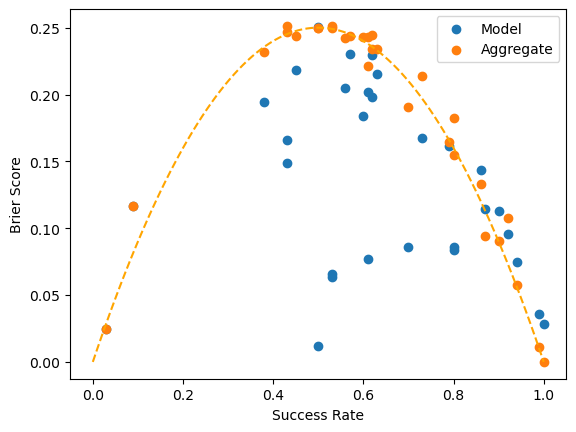

In [19]:

brierDFCopy = brierDF[:]

idxs = np.argsort(brierDFCopy["Success Score"])



plt.scatter(brierDFCopy["Success Score"][idxs], brierDF["Model Brier Score"][idxs], label="Model")
plt.scatter(brierDFCopy["Success Score"][idxs], brierDF["Aggregate Brier Scores"][idxs], label="Aggregate")


bernXVals = np.linspace(0,1, 100)
bernYVals = bernXVals*(1-bernXVals)

plt.plot(bernXVals, bernYVals, linestyle="dashed", color="orange")
plt.xlabel("Success Rate")
plt.ylabel("Brier Score")
#sns.set(font_scale=1)
plt.legend()

In [20]:
ability_lists = [objPermAbilityList, memoryAbilityList, flatNavAbilityList, visualAcuityAbilityList, lavaAbilityList, platformAbilityList, rampAbilityList, rightLeftBiasList]
agent_indices = list(range(0, numAgents))
ability_names = ["objPermAbility", "memoryAbility", "flatNavAbility", "visualAcuityAbility", "lavaAbility", "platformAbility", "rampAbility", "rightLeftBias"]


from arviz.labels import MapLabeller

for i, ability in enumerate(ability_names):
    az.plot_forest(
        [ability_lists[i][j] for j in agent_indices],
        model_names=[f"Agent {j+1}" for j in agent_indices],
        var_names=[ability],   # a real var name (so no KeyError)
        combined=True,
        hdi_prob=0.95,
        quartiles=False,
        legend=False,
        figsize=(10,10),
        labeller=MapLabeller(var_name_map={ability: ""}),  # nuke var label
    )
    plt.xlabel(ability)
    plt.savefig(f"figs/combined_forest_plot_{ability}_fullset.png",
                format="png", bbox_inches="tight")
    plt.close()

In [21]:
rows = []
for i, ability in enumerate(ability_names):
    for j in agent_indices:
        da = ability_lists[i][j]        # xarray.DataArray with dims ('chain','draw')
        v = da.values.reshape(-1)       # flatten chains × draws -> (samples,)
        rows.append(pd.DataFrame({
            "ability": ability,
            "agent": f"Agent {j}",
            "sample": np.arange(v.size, dtype=int),
            "value": v
        }))

df_long = pd.concat(rows, ignore_index=True)
df_long.to_csv("posteriors_long.csv", index=False)

Interesting Agents:
3, 5, 6, 9, 11




In [22]:
agent_indices = [2,4,5,8,10,12]


from arviz.labels import MapLabeller

for i, ability in enumerate(ability_names):
    az.plot_forest(
        [ability_lists[i][j] for j in agent_indices],
        model_names=[f"Agent {j+1}" for j in agent_indices],
        var_names=[ability],   # a real var name (so no KeyError)
        combined=True,
        hdi_prob=0.95,
        quartiles=False,
        legend=False,
        figsize=(10,10),
        labeller=MapLabeller(var_name_map={ability: ""}),  # nuke var label
    )
    plt.xlabel(ability)
    plt.savefig(f"figs/subset_combined_forest_plot_{ability}_fullset.svg",
                format="svg", bbox_inches="tight")
    plt.close()

In [23]:
 # write outputs to file to save compute later
abilityDF.to_csv('modelResults.csv', index = False)
meansDF.to_csv('abilityMeans.csv', index = False)

stdDevDF.to_csv('abilitySDs.csv', index=False)




In [24]:

abilityDF=abilityDF.set_index("Ability")

In [25]:
meansDF

,Ability,Agent1,Agent2,Agent3,Agent4,Agent5,Agent6,Agent7,Agent8,Agent9,...,Agent21,Agent22,Agent23,Agent24,Agent25,Agent26,Agent27,Agent28,Agent29,Agent30
0,objPermAbility,50.26,13.32,13.11,12.23,49.99,49.98,50.04,49.92,45.98,...,25.16,3.37,32.41,29.47,38.52,26.58,49.99,49.36,12.02,12.86
1,flatNavAbility,55.97,25.51,7.85,11.81,55.96,55.97,55.97,55.96,55.65,...,34.52,35.12,44.63,42.93,55.96,55.72,42.14,45.32,51.66,52.65
2,visualAcuityAbility,5.99,2.85,2.90,3.31,5.98,5.97,5.98,5.98,5.98,...,5.93,5.30,5.99,5.71,5.95,5.77,5.99,5.93,5.99,5.93
3,lavaAbility,1.00,0.49,0.50,0.49,0.99,0.08,0.82,0.92,0.99,...,0.63,0.47,1.00,0.96,0.99,0.98,1.00,0.84,1.00,0.99
4,platformAbility,1.00,0.50,0.49,0.41,0.99,0.99,0.98,0.98,0.99,...,0.99,0.95,0.00,0.02,1.00,0.99,1.00,0.93,0.99,0.92
5,rampAbility,1.00,0.49,0.49,0.41,0.99,1.00,1.00,0.99,0.13,...,0.66,0.77,1.00,0.95,0.64,0.51,1.00,0.99,0.71,0.67
6,memoryAbility,4.78,2.39,2.37,2.26,4.76,4.76,4.77,4.75,4.70,...,4.49,2.93,4.76,4.32,4.70,4.49,4.77,4.71,4.77,4.69
7,rightLeftBias,-0.03,0.01,-0.00,0.07,-0.34,-0.10,-0.03,-0.07,0.22,...,0.03,0.01,0.02,0.03,-0.02,0.50,-0.01,0.20,0.03,-0.07
8,noisePar,0.00,0.98,0.11,0.03,0.02,0.02,0.00,0.01,0.01,...,0.34,0.41,0.00,0.25,0.09,0.50,0.12,0.35,0.00,0.26
9,Success,1.00,0.50,0.09,0.03,0.90,0.53,0.86,0.87,0.61,...,0.43,0.38,0.50,0.43,0.73,0.57,0.70,0.56,0.80,0.62


In [26]:
abilityDF.T

Ability,objPermAbility,flatNavAbility,visualAcuityAbility,lavaAbility,platformAbility,rampAbility,memoryAbility,rightLeftBias,noisePar,Success
Agent1,"(50.26 , 1.5)","(55.97 , 0.03)","(5.99 , 0.01)","(1.0 , 0.0)","(1.0 , 0.0)","(1.0 , 0.0)","(4.78 , 0.02)","(-0.03 , 0.25)","(0.0 , 0.0)","(1.0 , 0.0)"
Agent2,"(13.32 , 11.6)","(25.51 , 16.08)","(2.85 , 1.71)","(0.49 , 0.28)","(0.5 , 0.28)","(0.49 , 0.29)","(2.39 , 1.37)","(0.01 , 1.02)","(0.98 , 0.02)","(0.5 , 0.5)"
Agent3,"(13.11 , 11.66)","(7.85 , 4.64)","(2.9 , 1.74)","(0.5 , 0.29)","(0.49 , 0.29)","(0.49 , 0.29)","(2.37 , 1.39)","(-0.0 , 0.98)","(0.11 , 0.01)","(0.09 , 0.29)"
Agent4,"(12.23 , 11.19)","(11.81 , 7.45)","(3.31 , 1.84)","(0.49 , 0.29)","(0.41 , 0.29)","(0.41 , 0.3)","(2.26 , 1.41)","(0.07 , 0.94)","(0.03 , 0.01)","(0.03 , 0.18)"
Agent5,"(49.99 , 1.53)","(55.96 , 0.04)","(5.98 , 0.02)","(0.99 , 0.01)","(0.99 , 0.01)","(0.99 , 0.01)","(4.76 , 0.04)","(-0.34 , 0.27)","(0.02 , 0.01)","(0.9 , 0.29)"
Agent6,"(49.98 , 1.5)","(55.97 , 0.04)","(5.97 , 0.03)","(0.08 , 0.01)","(0.99 , 0.01)","(1.0 , 0.0)","(4.76 , 0.04)","(-0.1 , 0.26)","(0.02 , 0.01)","(0.53 , 0.5)"
Agent7,"(50.04 , 1.51)","(55.97 , 0.03)","(5.98 , 0.02)","(0.82 , 0.02)","(0.98 , 0.01)","(1.0 , 0.0)","(4.77 , 0.03)","(-0.03 , 0.26)","(0.0 , 0.0)","(0.86 , 0.35)"
Agent8,"(49.92 , 1.46)","(55.96 , 0.04)","(5.98 , 0.02)","(0.92 , 0.02)","(0.98 , 0.01)","(0.99 , 0.01)","(4.75 , 0.05)","(-0.07 , 0.26)","(0.01 , 0.01)","(0.87 , 0.33)"
Agent9,"(45.98 , 3.43)","(55.65 , 0.31)","(5.98 , 0.02)","(0.99 , 0.0)","(0.99 , 0.0)","(0.13 , 0.01)","(4.7 , 0.09)","(0.22 , 0.63)","(0.01 , 0.01)","(0.61 , 0.49)"
Agent10,"(48.83 , 1.71)","(55.93 , 0.07)","(5.92 , 0.08)","(0.57 , 0.02)","(0.98 , 0.02)","(0.99 , 0.01)","(4.67 , 0.11)","(0.09 , 0.36)","(0.2 , 0.03)","(0.63 , 0.48)"


In [27]:
abilityMax

{'memoryAbility': 4.8,
 'objPermAbility': 52.8,
 'visualAcuityAbility': 6.0,
 'flatNavAbility': 56,
 'lavaAbility': 1,
 'platformAbility': 1,
 'rampAbility': 1,
 'rightLeftBias': inf,
 'rednessBias': inf,
 'greennessBias': inf,
 'bluenessBias': inf}

In [28]:
meansDF = pd.read_csv("abilityMeans.csv", index_col=None)
meansDF = meansDF.set_index("Ability")

sdsDF = pd.read_csv("abilitySDs.csv", index_col=None)
sdsDF = sdsDF.set_index("Ability")
abilitiesToShow = ["objPermAbility", "flatNavAbility", "visualAcuityAbility","lavaAbility", "platformAbility", "rampAbility", "memoryAbility", "rightLeftBias", "noisePar", "Success"]

annosDF =pd.read_csv("abilityMeans.csv", index_col=None)
annosDF = annosDF.set_index("Ability")
meansAndSDsDF = pd.read_csv("modelResults.csv", index_col=None)

In [30]:
##### Helper function to max-min normalize the variables
def scaleVector(vect, min, max):
  scaledVect = (vect - min)/(max-min)
  return scaledVect

In [31]:

meansDFScaled = meansDF.T

meansDFScaled["objPermAbility"] = scaleVector(meansDFScaled["objPermAbility"], abilityMin["objPermAbility"], abilityMax["objPermAbility"]) #Scale based on max theoretical OP
meansDFScaled["flatNavAbility"] = scaleVector(meansDFScaled["flatNavAbility"], np.min(meansDFScaled["flatNavAbility"]), np.max(meansDFScaled["flatNavAbility"])) #scale based on max Nav ability in database
meansDFScaled["visualAcuityAbility"] = scaleVector(meansDFScaled["visualAcuityAbility"], abilityMin["visualAcuityAbility"], abilityMax["visualAcuityAbility"]) #Scale based on max theoretical visual ability
meansDFScaled["memoryAbility"] = scaleVector(meansDFScaled["memoryAbility"], abilityMin["memoryAbility"], abilityMax["memoryAbility"]) #Scale based on max theoretical visual ability


annosDFScaled = meansDFScaled



In [32]:
print(meansDFScaled, abilityMax)

Ability  objPermAbility  flatNavAbility  visualAcuityAbility  lavaAbility  \
Agent1         0.951894        1.000000             0.998333         1.00   
Agent2         0.252273        0.366999             0.475000         0.49   
Agent3         0.248295        0.000000             0.483333         0.50   
Agent4         0.231629        0.082294             0.551667         0.49   
Agent5         0.946780        0.999792             0.996667         0.99   
Agent6         0.946591        1.000000             0.995000         0.08   
Agent7         0.947727        1.000000             0.996667         0.82   
Agent8         0.945455        0.999792             0.996667         0.92   
Agent9         0.870833        0.993350             0.996667         0.99   
Agent10        0.924811        0.999169             0.986667         0.57   
Agent11        0.911364        0.999584             0.605000         0.98   
Agent12        0.932386        0.906484             0.973333         0.99   

Ability  objPermAbility  flatNavAbility  visualAcuityAbility  lavaAbility  \
Agent1            50.26           55.97                 5.99         1.00   
Agent2            13.32           25.51                 2.85         0.49   
Agent3            13.11            7.85                 2.90         0.50   
Agent4            12.23           11.81                 3.31         0.49   
Agent5            49.99           55.96                 5.98         0.99   
Agent6            49.98           55.97                 5.97         0.08   
Agent7            50.04           55.97                 5.98         0.82   
Agent8            49.92           55.96                 5.98         0.92   
Agent9            45.98           55.65                 5.98         0.99   
Agent10           48.83           55.93                 5.92         0.57   
Agent11           48.12           55.95                 3.63         0.98   
Agent12           49.23           51.47                 5.84         0.99   

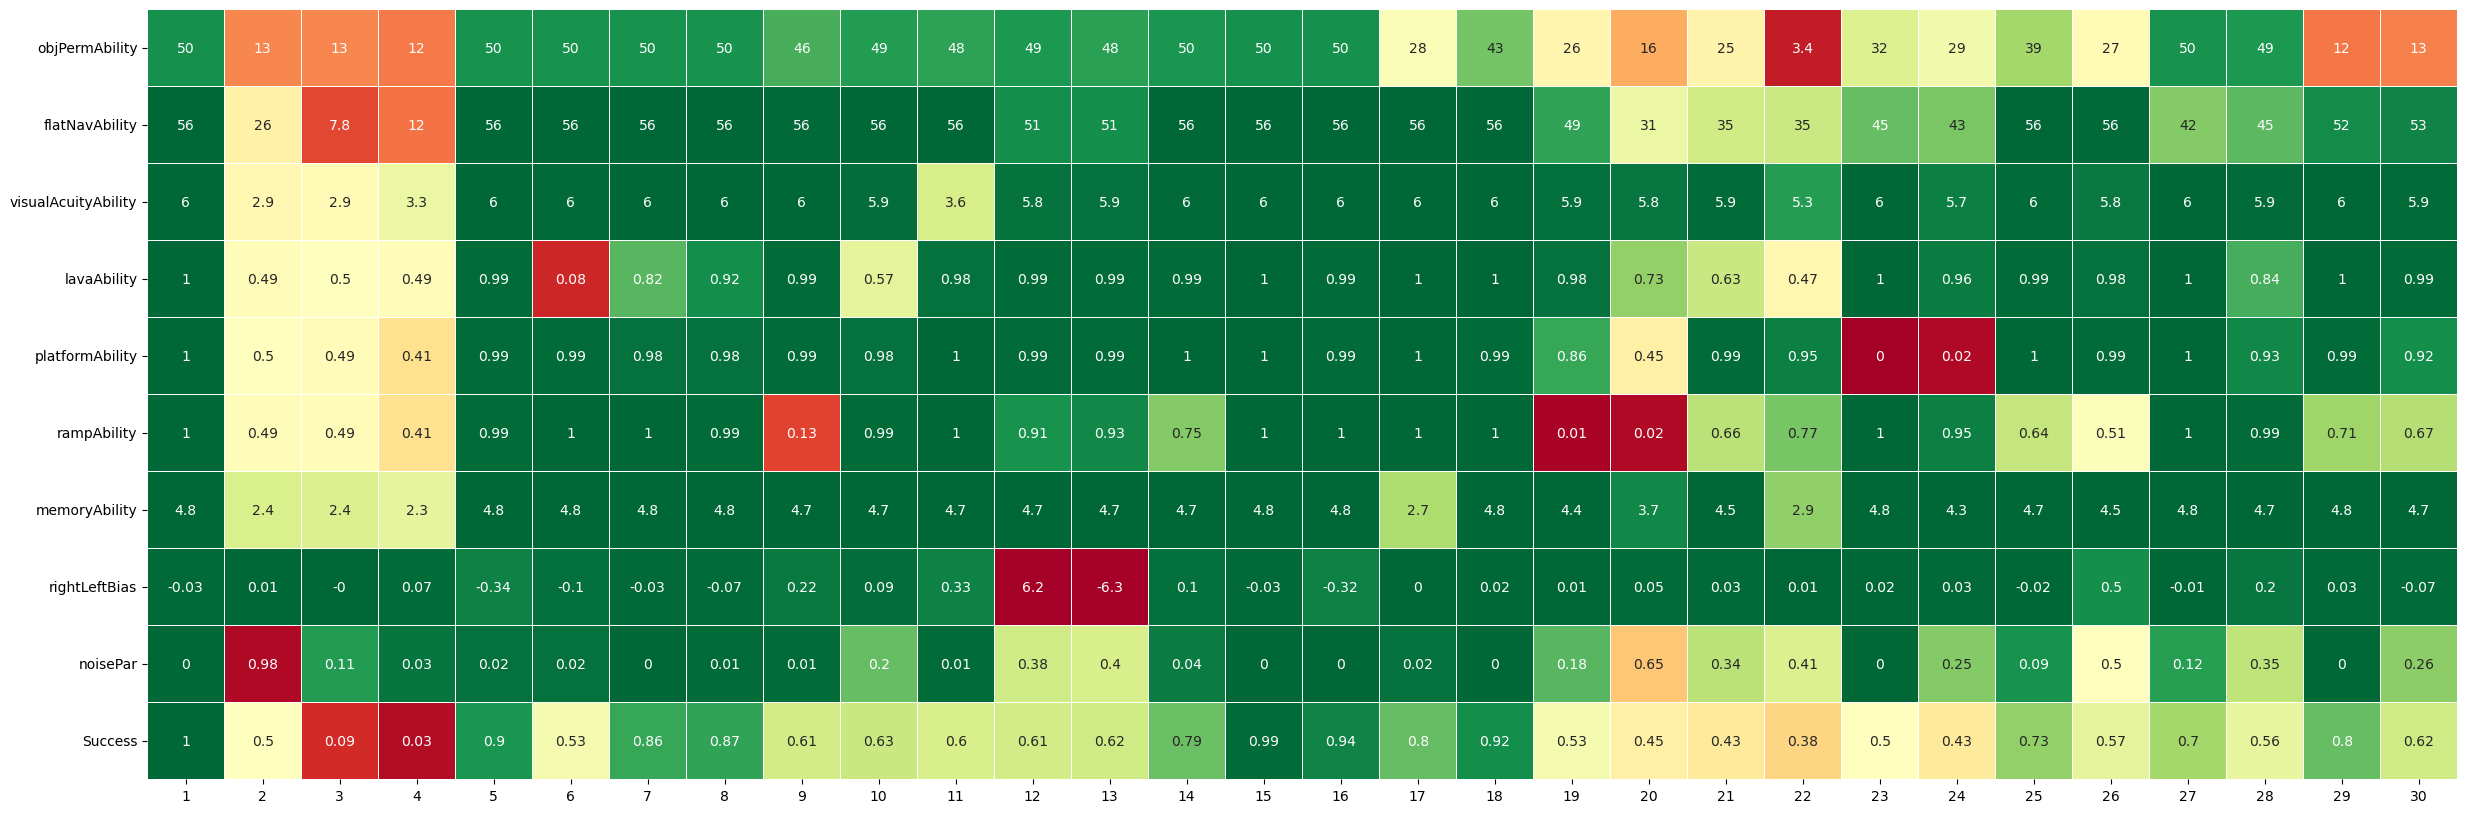

In [ ]:



print(meansDF.T)

# change fig dimensions
f, axs = plt.subplots(len(abilitiesToShow), 1)
f.set_figwidth(40)
f.set_figheight(10)

annotsToPlot=annosDF.T

meansToPlot=meansDF.T
print(meansDF)
meansToPlot["rightLeftBias"] = 0-meansToPlot["rightLeftBias"].abs()
meansToPlot["noisePar"] = 0-meansToPlot["noisePar"]

# plot heatmap with some parameters

xlabels = list(range(1,31))
vmins = [0, 0 , 0, 0, 0, 0,0,-6,-1,0]
vmaxs = [55,56, 6, 1,1,1, 4, 0,0,1]

for i in range(0,len(abilitiesToShow)):
  b=np.asarray(meansToPlot[abilitiesToShow[i]])[:30].reshape(1,30)
  an = np.asarray(annotsToPlot[abilitiesToShow[i]])[:30].reshape(1,30)

  plt.subplots_adjust(hspace=0, wspace=0)

  g=sns.heatmap(b, square=True, linewidths = .5, annot = an, fmt=".2g", cmap = 'RdYlGn', vmin = vmins[i], vmax = vmaxs[i], ax=axs.flat[i], cbar=False, yticklabels=[abilitiesToShow[i]], xticklabels=xlabels) # heat map with separators between boxes, annotations of ability numbers, and colour palette
  g.tick_params(axis='y', rotation=0)
  g.tick_params(axis='x', rotation=0)
  if i < len(abilitiesToShow)-1:
        axs.flat[i].xaxis.set_ticks([])


sns.set(font_scale=1.75)    
plt.show()

Ability  objPermAbility  flatNavAbility  visualAcuityAbility  lavaAbility  \
Agent1             1.50            0.03                 0.01         0.00   
Agent2            11.60           16.08                 1.71         0.28   
Agent3            11.66            4.64                 1.74         0.29   
Agent4            11.19            7.45                 1.84         0.29   
Agent5             1.53            0.04                 0.02         0.01   
Agent6             1.50            0.04                 0.03         0.01   
Agent7             1.51            0.03                 0.02         0.02   
Agent8             1.46            0.04                 0.02         0.02   
Agent9             3.43            0.31                 0.02         0.00   
Agent10            1.71            0.07                 0.08         0.02   
Agent11            2.19            0.05                 0.06         0.01   
Agent12            1.69            0.35                 0.13         0.01   

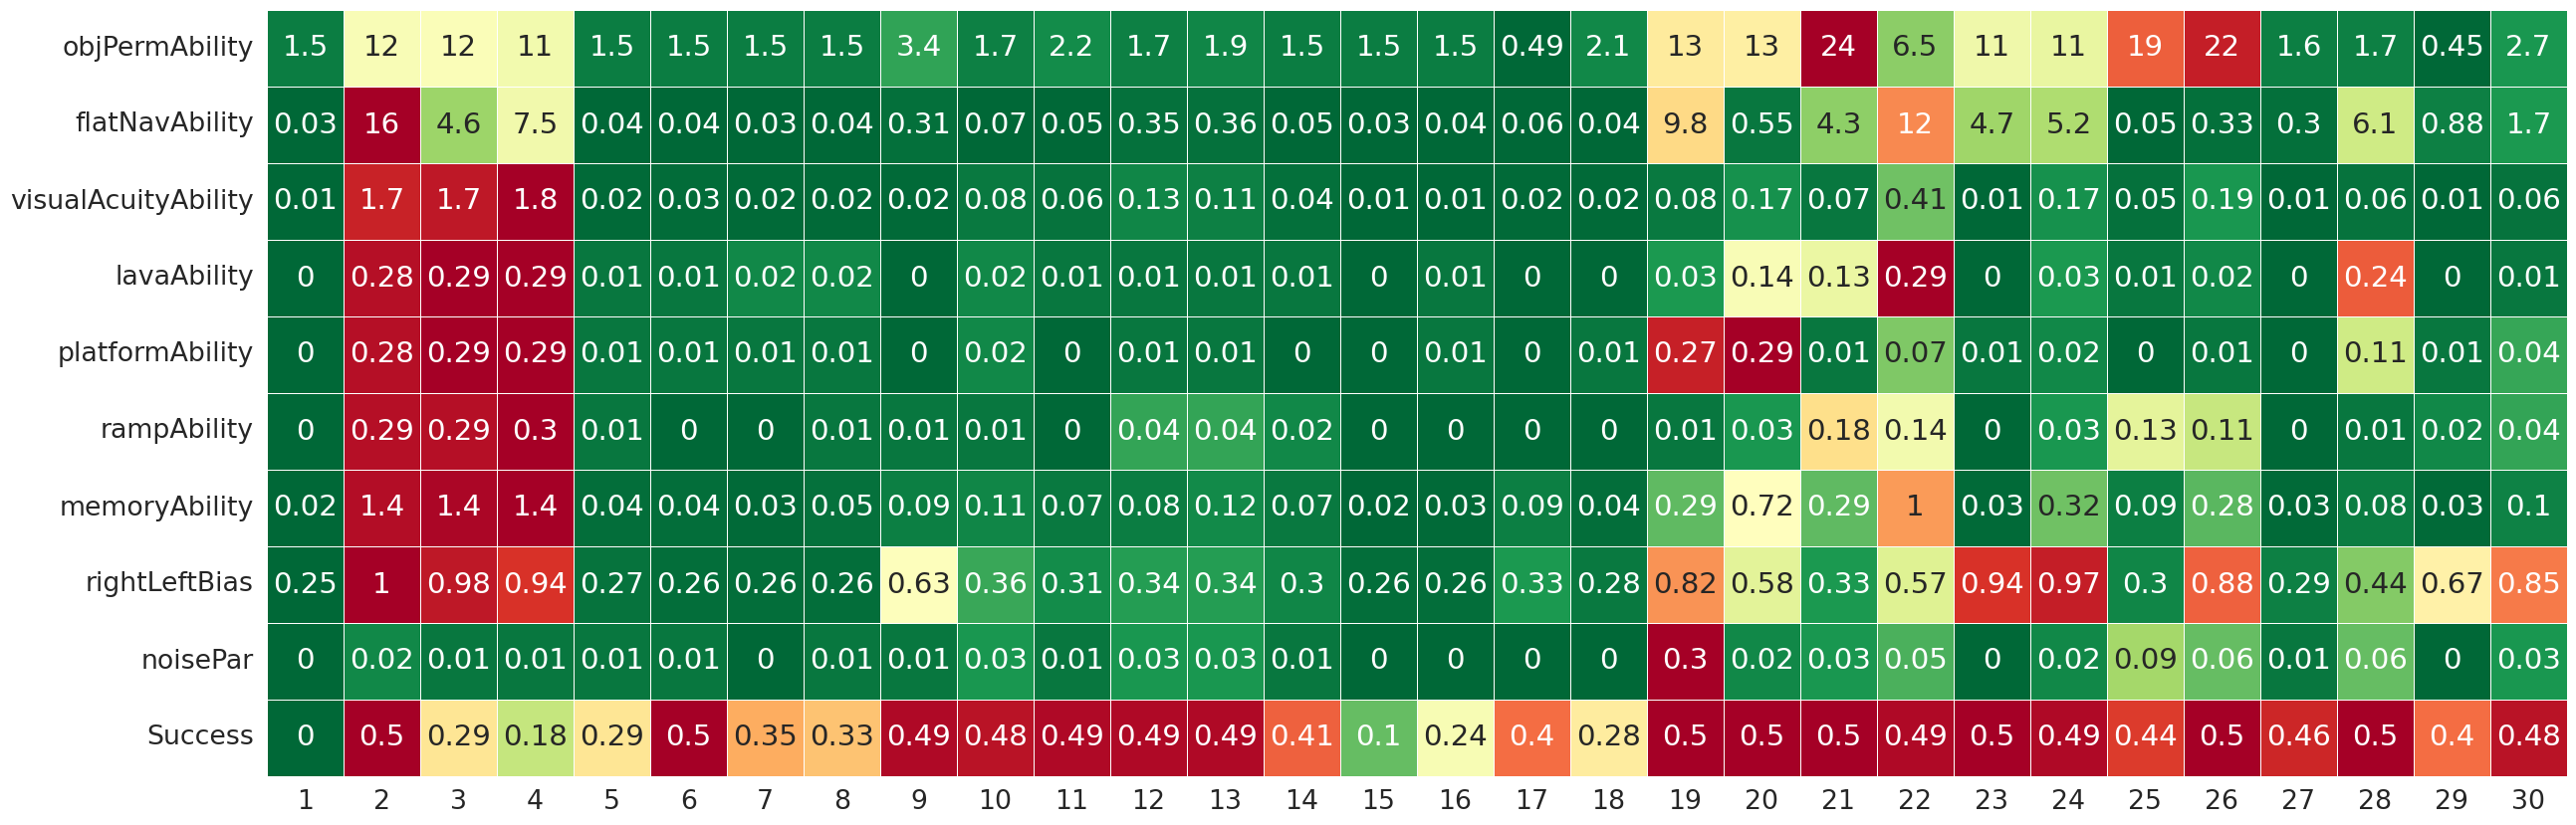

In [34]:

#Make same plot for SDs

# change fig dimensions
f, axs = plt.subplots(len(abilitiesToShow), 1)
f.set_figwidth(40)
f.set_figheight(10)


sdsToPlot=sdsDF.T
print(sdsToPlot)


xlabels = list(range(1,31))


for i in range(0,len(abilitiesToShow)):

  b=np.asarray(sdsToPlot[abilitiesToShow[i]])[:30].reshape(1,30)

  plt.subplots_adjust(hspace=0, wspace=0)

  g=sns.heatmap(b, square=True, linewidths = .5, annot=b, fmt=".2g", cmap = 'RdYlGn_r', ax=axs.flat[i], cbar=False, yticklabels=[abilitiesToShow[i]], xticklabels=xlabels) # heat map with separators between boxes, annotations of ability numbers, and colour palette
  g.tick_params(axis='y', rotation=0)
  g.tick_params(axis='x', rotation=0)
  if i < len(abilitiesToShow)-1:
        axs.flat[i].xaxis.set_ticks([])


sns.set(font_scale=1.75)
plt.show()